In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Amazon sales Data.csv', encoding='unicode_escape')

In [3]:
df.shape

(100, 6)

In [4]:
df.head()

,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count
0,AZ1001,Power Bank Model-39,Audio,591.53,4.1,4399
1,AZ1002,External SSD Model-20,Accessories,647.02,3.6,9779
2,AZ1003,Smart Watch Model-72,Accessories,419.88,4.7,9704
3,AZ1004,Graphics Card Model-97,Electronics,214.91,4.8,6305
4,AZ1005,Mechanical Keyboard Model-53,Computers,1002.45,4.1,8880


In [8]:
pd.isnull(df)
#show true/false values

,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
95,False,False,False,False,False,False
96,False,False,False,False,False,False
97,False,False,False,False,False,False
98,False,False,False,False,False,False


In [10]:
pd.isnull(df).sum()

Product_ID      0
Product_Name    0
Category        0
Price_USD       0
Rating          0
Review_Count    0
dtype: int64

In [11]:
df.shape

(100, 6)

In [13]:
df.dropna(inplace=True)

In [14]:
df.shape

(100, 6)

In [18]:
#change data type
df['Rating']=df['Rating'].astype('int')

In [20]:
df['Rating'].dtypes

dtype('int64')

In [22]:
df.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Price_USD', 'Rating',
       'Review_Count'],
      dtype='str')

In [28]:
df.rename(columns={'Price_USD':'Amount'})

,Product_ID,Product_Name,Category,Amount,Rating,Review_Count
0,AZ1001,Power Bank Model-39,Audio,591.53,4,4399
1,AZ1002,External SSD Model-20,Accessories,647.02,3,9779
2,AZ1003,Smart Watch Model-72,Accessories,419.88,4,9704
3,AZ1004,Graphics Card Model-97,Electronics,214.91,4,6305
4,AZ1005,Mechanical Keyboard Model-53,Computers,1002.45,4,8880
...,...,...,...,...,...,...
95,AZ1096,USB-C Hub Model-39,Accessories,441.43,4,2072
96,AZ1097,Webcam Pro Model-65,Computers,188.85,3,2074
97,AZ1098,USB-C Hub Model-83,Audio,47.43,3,3840
98,AZ1099,External SSD Model-31,Computers,1040.16,4,7714


In [29]:
df.describe()

,Price_USD,Rating,Review_Count
count,100.000000,100.000000,100.000000
mean,738.974900,3.800000,4834.210000
std,415.807278,0.492366,2767.290471
min,23.230000,3.000000,266.000000
25%,410.757500,4.000000,2666.000000
50%,689.010000,4.000000,4463.000000
75%,1117.355000,4.000000,7308.500000
max,1476.800000,5.000000,9953.000000


In [30]:
df[['Price_USD' ,'Rating']].describe()

,Price_USD,Rating
count,100.000000,100.000000
mean,738.974900,3.800000
std,415.807278,0.492366
min,23.230000,3.000000
25%,410.757500,4.000000
50%,689.010000,4.000000
75%,1117.355000,4.000000
max,1476.800000,5.000000


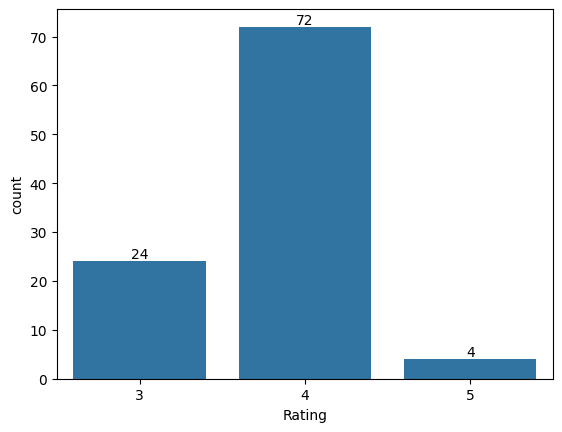

In [34]:
ax=sns.countplot(x='Rating',data=df)
for bars in ax.containers:
    ax.bar_label(bars)
    #count the no of values in a container 

<Axes: xlabel='Category', ylabel='Price_USD'>

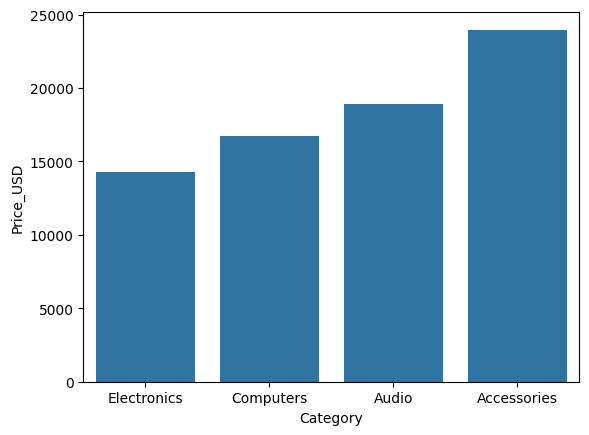

In [37]:
sales_gen = df.groupby(['Category'], as_index=False)['Price_USD'].sum().sort_values(by='Category',ascending=False)
sns.barplot(x='Category',y='Price_USD' ,data=sales_gen)

In [39]:
df.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Price_USD', 'Rating',
       'Review_Count'],
      dtype='str')

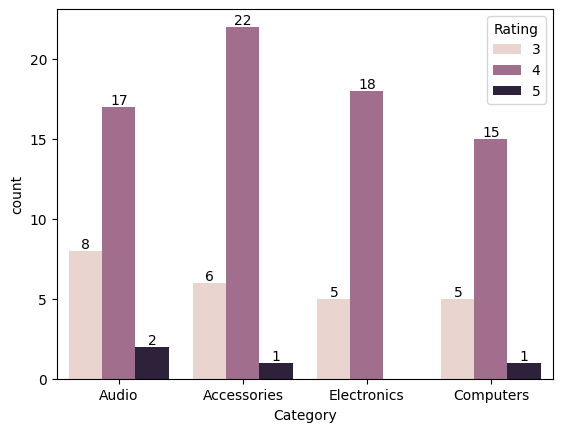

In [45]:
ax=sns.countplot(x='Category', hue='Rating' ,data=df)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Category', ylabel='Review_Count'>

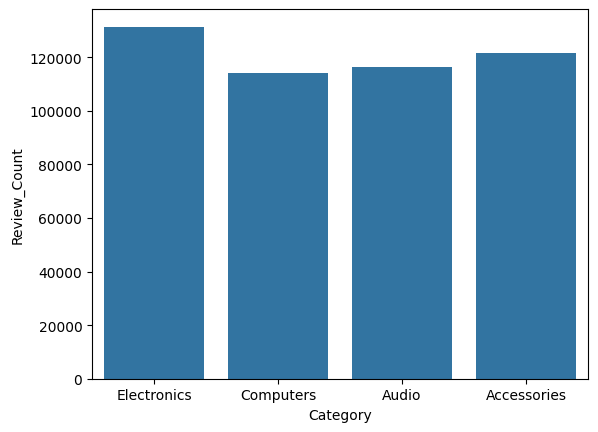

In [47]:
sales_gen = df.groupby(['Category'], as_index=False)['Review_Count'].sum().sort_values(by='Category',ascending=False)
sns.barplot(x='Category',y='Review_Count' ,data=sales_gen)

<Axes: xlabel='Category', ylabel='Price_USD'>

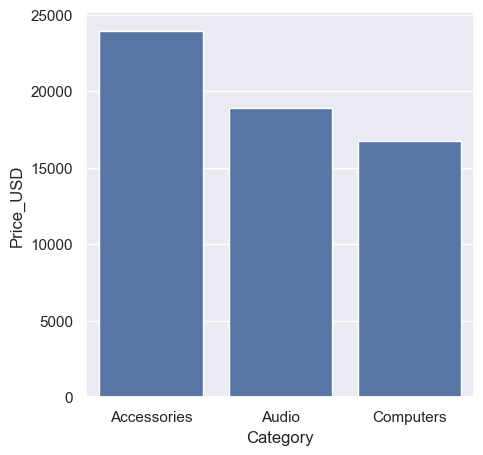

In [54]:
#total price in usd from top 3 category
sales_Category=df.groupby(['Category'],as_index=False)['Price_USD'].sum().sort_values(by='Price_USD',ascending=False).head(3)
sns.set(rc={'figure.figsize':(5,5)})
sns.barplot(data=sales_Category,x='Category',y='Price_USD')


<Axes: xlabel='Product_Name', ylabel='Price_USD'>

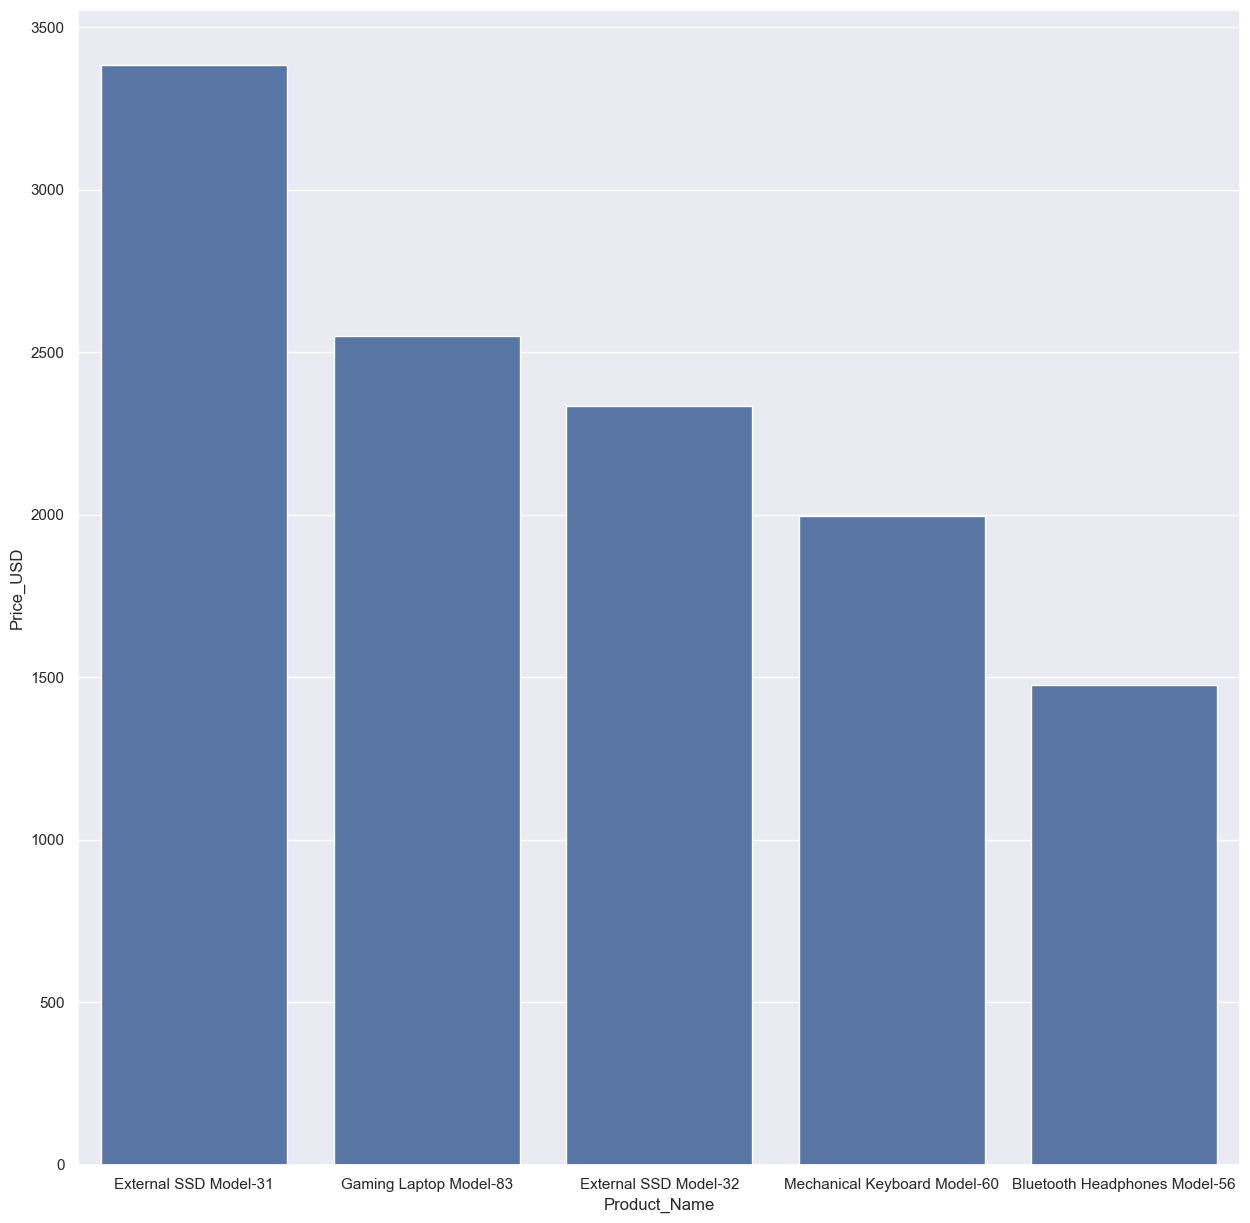

In [70]:
sales_Category=df.groupby(['Product_Name'],as_index=False)['Price_USD'].sum().sort_values(by='Price_USD',ascending=False).head(5)
sns.set(rc={'figure.figsize':(15,15)})
sns.barplot(data=sales_Category,x='Product_Name',y='Price_USD')

<Axes: xlabel='Product_Name', ylabel='Rating'>

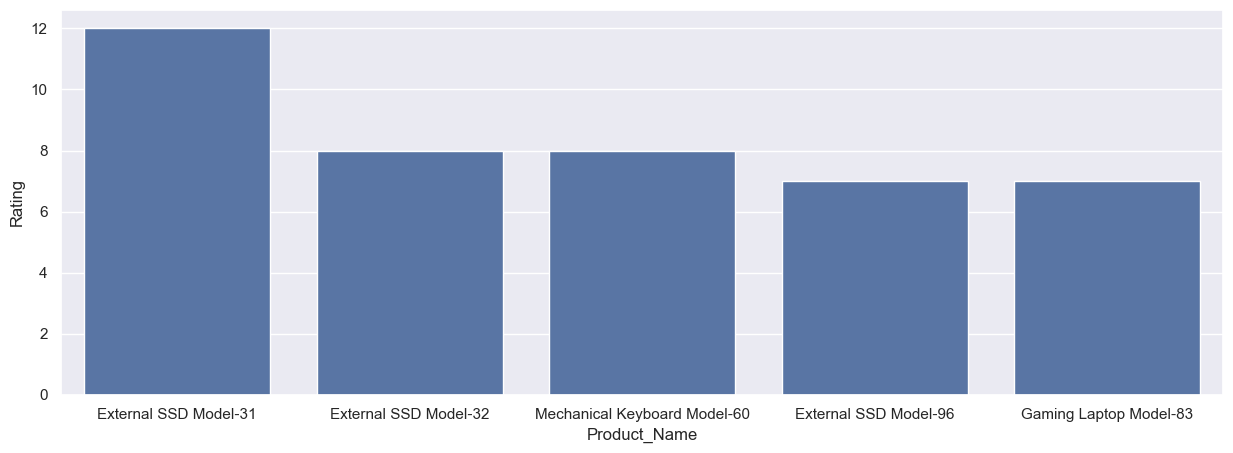

In [86]:
sales_Category=df.groupby(['Product_Name'],as_index=False)['Rating'].sum().sort_values(by='Rating',ascending=False).head(5)
sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data=sales_Category,x='Product_Name',y='Rating')

<Axes: xlabel='Product_Name'>

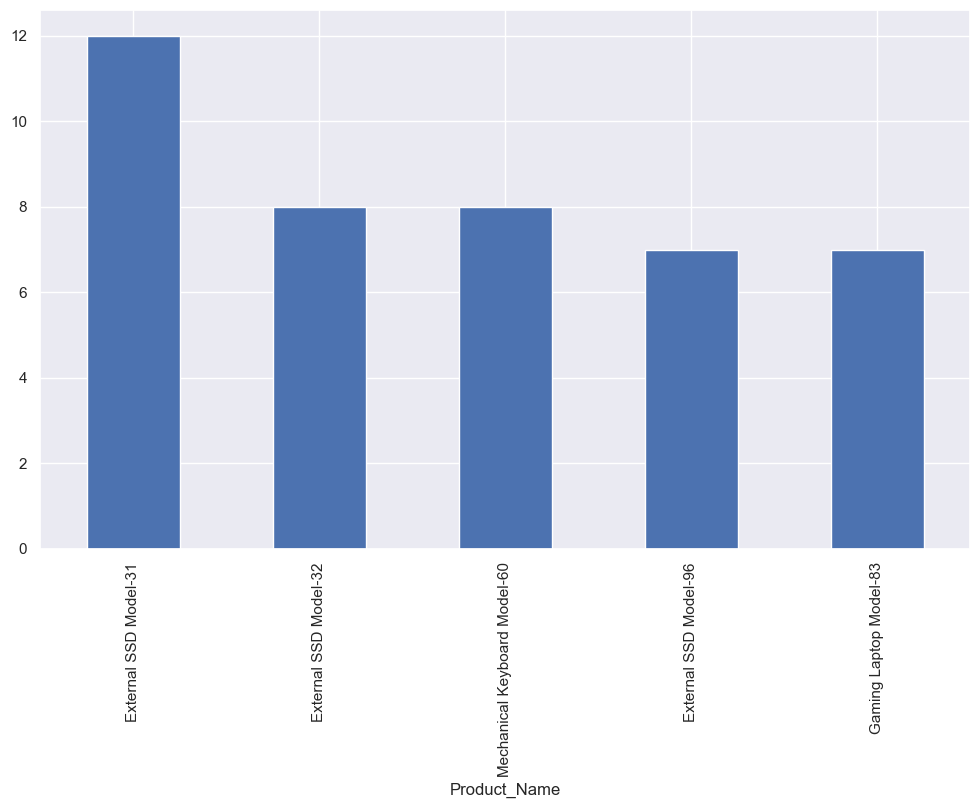

In [89]:
#most sold products
fig1, ax1 = plt.subplots(figsize=(12,7))
df.groupby('Product_Name')['Rating'].sum().nlargest(5).sort_values(ascending=False).plot(kind='bar')